# 01 · EDA — Global Forest Watch (GFW)
Análisis exploratorio del dataset raw de alertas de deforestación.  
**Objetivo:** entender la estructura, calidad y distribución de los datos *antes* de transformar.  
Los hallazgos de esta sección guían las decisiones de transformación en `05_etl_pipeline.ipynb`.

Fuente: `data/csv/bol_alerts_*.csv` y `col_alerts_*.csv` (descargados por `scripts/batch_download.py`)

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from glob import glob

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_CSV = Path('../data/csv')
RES      = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

COUNTRIES = {'BOL': 'Bolivia', 'COL': 'Colombia'}

def find_csv(code):
    files = sorted(DATA_CSV.glob(f'{code.lower()}_alerts_*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV encontrado para {code} en {DATA_CSV}')
    return files[-1]   # el más reciente

print('CSVs disponibles:')
for code in COUNTRIES:
    try:
        p = find_csv(code)
        print(f'  {code}: {p.name}  ({p.stat().st_size/1e6:.1f} MB)')
    except FileNotFoundError as e:
        print(f'  ⚠️  {e}')

CSVs disponibles:
  BOL: bol_alerts_2022-01-01_2026-07-31.csv  (48.2 MB)
  COL: col_alerts_2022-01-01_2026-07-31.csv  (51.7 MB)


## 1. Carga y estructura

In [2]:
frames = {}
for code, name in COUNTRIES.items():
    df = pd.read_csv(find_csv(code), parse_dates=['gfw_integrated_alerts__date'])
    frames[code] = df
    print(f'{name} ({code}): {len(df):>10,} filas | {df.shape[1]} columnas')

print(f'\nTotal: {sum(len(f) for f in frames.values()):,} filas')
print('\nColumnas:')
for col in frames['BOL'].columns:
    print(f'  {col}: {frames["BOL"][col].dtype}')

Bolivia (BOL):    724,000 filas | 12 columnas
Colombia (COL):    799,990 filas | 12 columnas

Total: 1,523,990 filas

Columnas:
  latitude: float64
  longitude: float64
  gfw_integrated_alerts__date: datetime64[us]
  gfw_integrated_alerts__confidence: str
  gfw_integrated_alerts__intensity: int64
  umd_tree_cover_density_2000__percent: int64
  is__umd_regional_primary_forest_2001: int64
  wdpa_protected_areas__iucn_cat: int64
  esa_land_cover_2015__class: str
  wri_google_tree_cover_loss_drivers__category: int64
  gadm_administrative_boundaries__adm1: int64
  is__umd_soy_planted_area_buffered_10km: int64


In [3]:
# Muestra de filas
frames['BOL'].head(3)

,latitude,longitude,gfw_integrated_alerts__date,gfw_integrated_alerts__confidence,gfw_integrated_alerts__intensity,umd_tree_cover_density_2000__percent,is__umd_regional_primary_forest_2001,wdpa_protected_areas__iucn_cat,esa_land_cover_2015__class,wri_google_tree_cover_loss_drivers__category,gadm_administrative_boundaries__adm1,is__umd_soy_planted_area_buffered_10km
0,-13.03755,-68.11865,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
1,-13.03795,-68.11835,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
2,-13.03825,-68.11765,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0


## 2. Calidad de datos
> **Decisiones de transformación que se derivan de esta sección:**
> - Columnas con nulos → estrategia de imputación o exclusión
> - Duplicados → deduplicar antes de migrar
> - Valores anómalos en `adm1_code` → mapear a 'Desconocido'
> - Columna `confidence` → derivar flag binario `is_high_confidence`

In [4]:
for code, df in frames.items():
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(2)
    dups     = df.duplicated().sum()
    date_col = 'gfw_integrated_alerts__date'

    print(f'\n── {COUNTRIES[code]} ({code}) ──')
    print(f'  Filas: {len(df):,} | Columnas: {df.shape[1]}')
    print(f'  Duplicados: {dups:,}')
    print(f'  Rango fechas: {df[date_col].min().date()} → {df[date_col].max().date()}')
    print('  Nulos por columna:')
    nulos = pd.DataFrame({'nulls': nulls, 'null_%': null_pct})
    nulos_presentes = nulos[nulos['nulls'] > 0]
    if nulos_presentes.empty:
        print('    Sin valores nulos')
    else:
        print(nulos_presentes.to_string())


── Bolivia (BOL) ──
  Filas: 724,000 | Columnas: 12
  Duplicados: 0
  Rango fechas: 2022-01-01 → 2026-07-30
  Nulos por columna:
                            nulls  null_%
esa_land_cover_2015__class    174    0.02

── Colombia (COL) ──
  Filas: 799,990 | Columnas: 12
  Duplicados: 0
  Rango fechas: 2022-01-01 → 2026-07-30
  Nulos por columna:
                            nulls  null_%
esa_land_cover_2015__class  27037    3.38


## 3. Distribución de variables categóricas

In [5]:
for code, df in frames.items():
    print(f'\n── {COUNTRIES[code]} ({code}) ──')
    print('  confidence:', df['gfw_integrated_alerts__confidence'].value_counts().to_dict())
    print('  loss_driver:', df['wri_google_tree_cover_loss_drivers__category'].value_counts().to_dict())
    print('  is_primary_forest:', df['is__umd_regional_primary_forest_2001'].value_counts().to_dict())
    print('  adm1_code únicos:', sorted(df['gadm_administrative_boundaries__adm1'].dropna().unique().tolist()))


── Bolivia (BOL) ──
  confidence: {'high': 455225, 'highest': 248071, 'nominal': 20704}
  loss_driver: {1: 310799, 5: 156680, 7: 98671, 255: 70499, 3: 41150, 4: 38673, 2: 6313, 6: 1215}
  is_primary_forest: {1: 676781, 0: 47219}
  adm1_code únicos: [1, 2, 3, 4, 6, 8, 9, 17, 18, 22, 9999]

── Colombia (COL) ──
  confidence: {'high': 595301, 'highest': 158763, 'nominal': 45926}
  loss_driver: {1: 475163, 255: 125237, 3: 103116, 7: 38183, 4: 36934, 2: 19067, 5: 1286, 6: 1004}
  is_primary_forest: {1: 640254, 0: 159736}
  adm1_code únicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 9999]


## 4. Distribución temporal

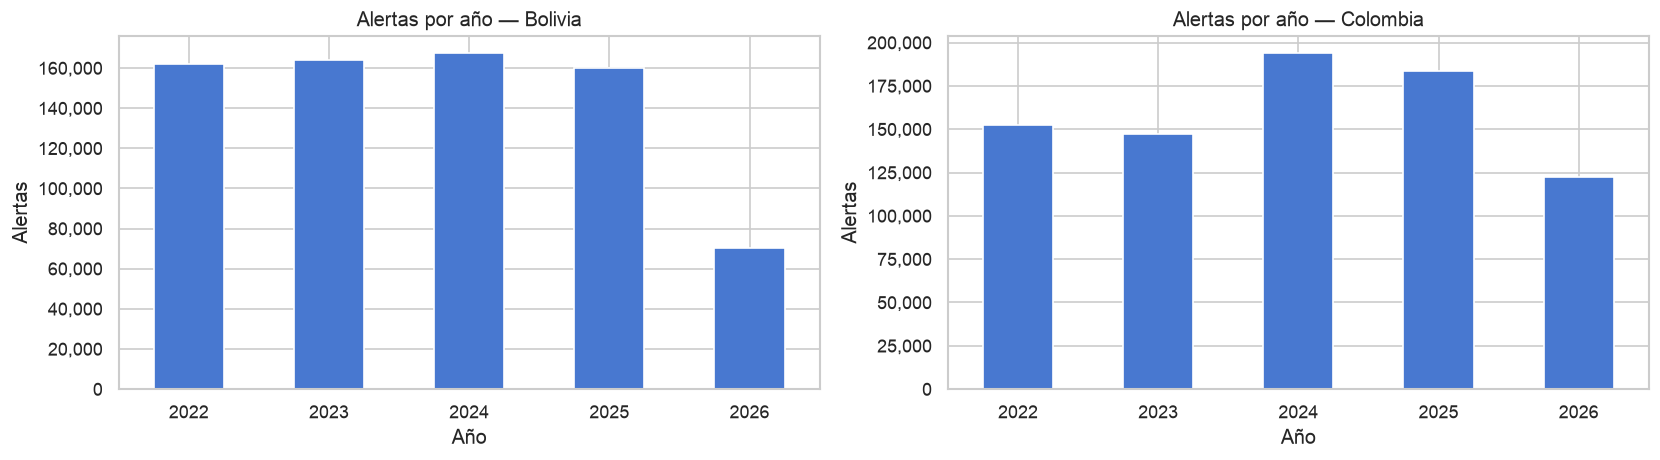

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    df['gfw_integrated_alerts__date'].dt.year.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f'Alertas por año — {COUNTRIES[code]}')
    ax.set_xlabel('Año'); ax.set_ylabel('Alertas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_alertas_por_anio.png', dpi=120)
plt.show()

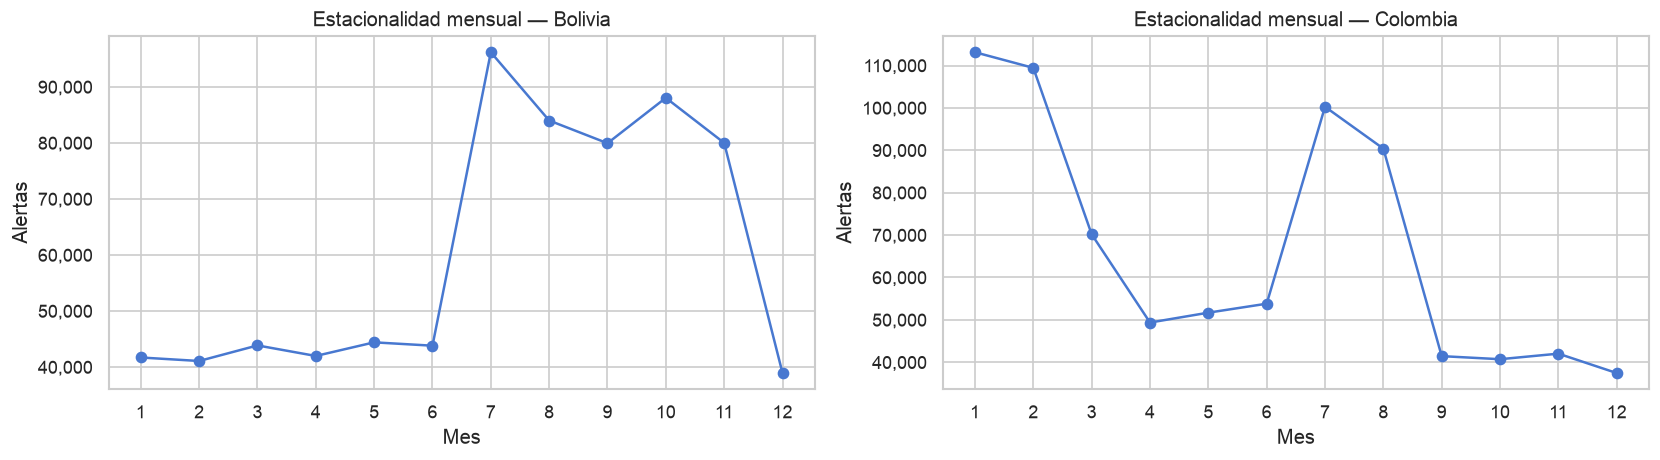

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    df['gfw_integrated_alerts__date'].dt.month.value_counts().sort_index().plot(ax=ax, marker='o')
    ax.set_title(f'Estacionalidad mensual — {COUNTRIES[code]}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Alertas')
    ax.set_xticks(range(1, 13))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_estacionalidad.png', dpi=120)
plt.show()

## 5. Distribución de densidad de cobertura arbórea

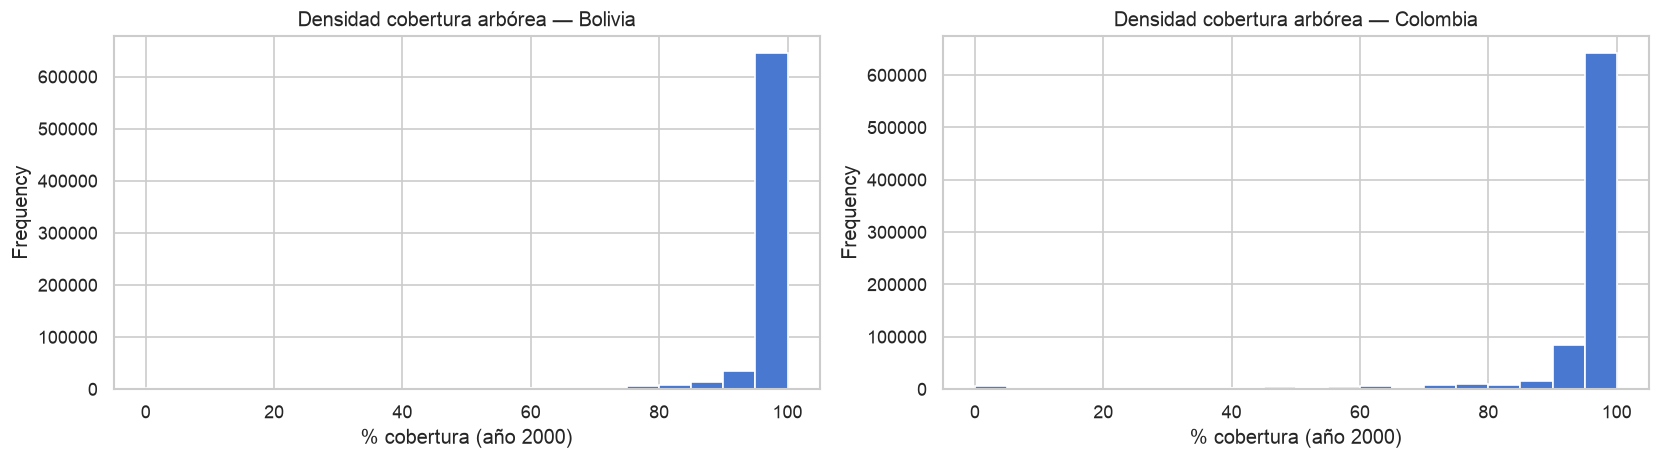

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    col = 'umd_tree_cover_density_2000__percent'
    df[col].dropna().plot(kind='hist', bins=20, ax=ax)
    ax.set_title(f'Densidad cobertura arbórea — {COUNTRIES[code]}')
    ax.set_xlabel('% cobertura (año 2000)')
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_densidad_cobertura.png', dpi=120)
plt.show()

## 6. Hallazgos y decisiones de transformación

| Hallazgo | Decisión |
|----------|----------|
| `land_cover_class` tiene nulos (BOL 0.02%, COL 3.38%) | Mantener nulos → FK nullable en `fact_alerts` |
| `adm1_code` tiene valores fuera del mapa (17, 18, 22, 9999 en BOL) | Mapear a `adm1_code = -1` / `adm1_name = 'Desconocido'` |
| `confidence` tiene 3 valores: nominal, high, highest | Derivar `is_high_confidence = 1` si high/highest |
| `loss_driver_category` usa código 255 para sin clasificar | Mapear explícitamente a 'Sin clasificar' |
| 0 duplicados en ambos países | No se requiere deduplicación |
| Columnas con nombres largos tipo `gfw_integrated_alerts__date` | Renombrar a nombres cortos en transformación |